## ПРОБНЫЙ ФАЙЛ ПО РАСЧЕТУ TP(TOTAL POWER) - СУММАРНАЯ МОЩНОСТЬ СПЕКТРА ВСР

##

### Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

### Загрузка файла

In [2]:
R_R = np.loadtxt('RR_2.csv',
				delimiter=",", dtype=int)

Кардиоинтервалограмма без интерполяции

In [3]:
x = np.arange(0,len(R_R))

Text(0, 0.5, 'Длительность интервала, мс')

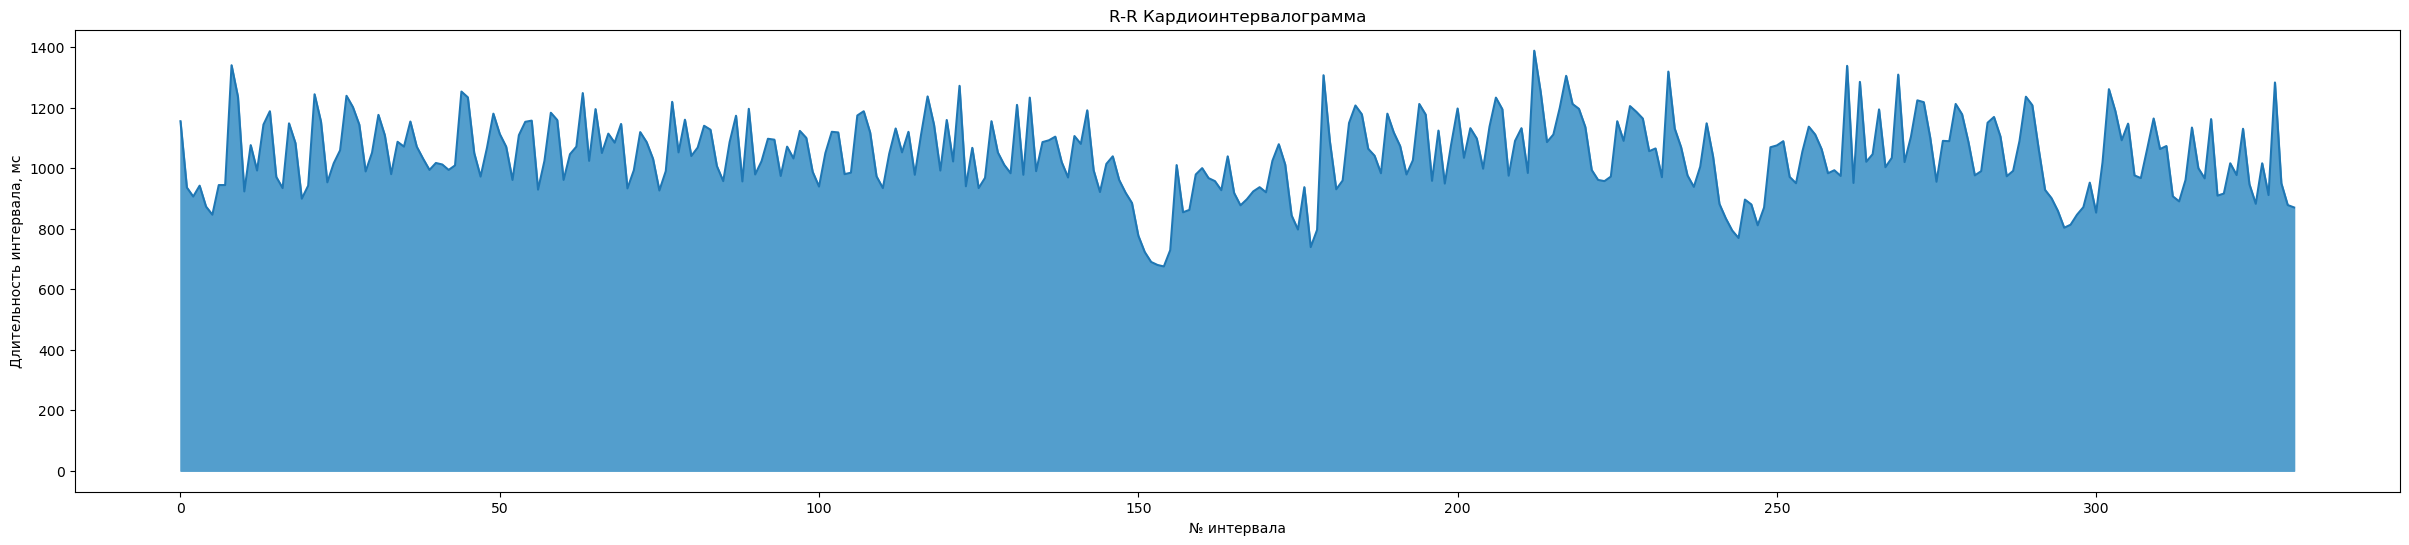

In [4]:
plt.figure(figsize=(30,6))
plt.plot(x,R_R,)
plt.title('R-R Кардиоинтервалограмма')
plt.fill_between(x, R_R, color='#539ecd')
plt.xlabel('№ интервала')
plt.ylabel('Длительность интервала, мс')

Переводим в секунды кардиоинтерваллограмму

In [5]:
R_R_sec = R_R / 1000

Интерполяция:
1. высчитываем временную шкалу

In [6]:
time_steps = np.cumsum(R_R_sec)

2. Делаем шкалу с частотой дискретизации 0.25

In [7]:
new_time = np.arange(time_steps[0], time_steps[-1], 0.25)

3. используем для отображения на новую шкалу кубическую интерполяцию

In [8]:
spline_model = CubicSpline(time_steps, R_R_sec)
R_R_interp = spline_model(new_time)

Центрирование данных

In [9]:
R_R_centered = R_R_interp - np.mean(R_R_interp)

### Ритмограмма R-R Интерполированные Аппаратные данные

Настройка графика

Text(0, 0.5, 'Длительность интервала, с')

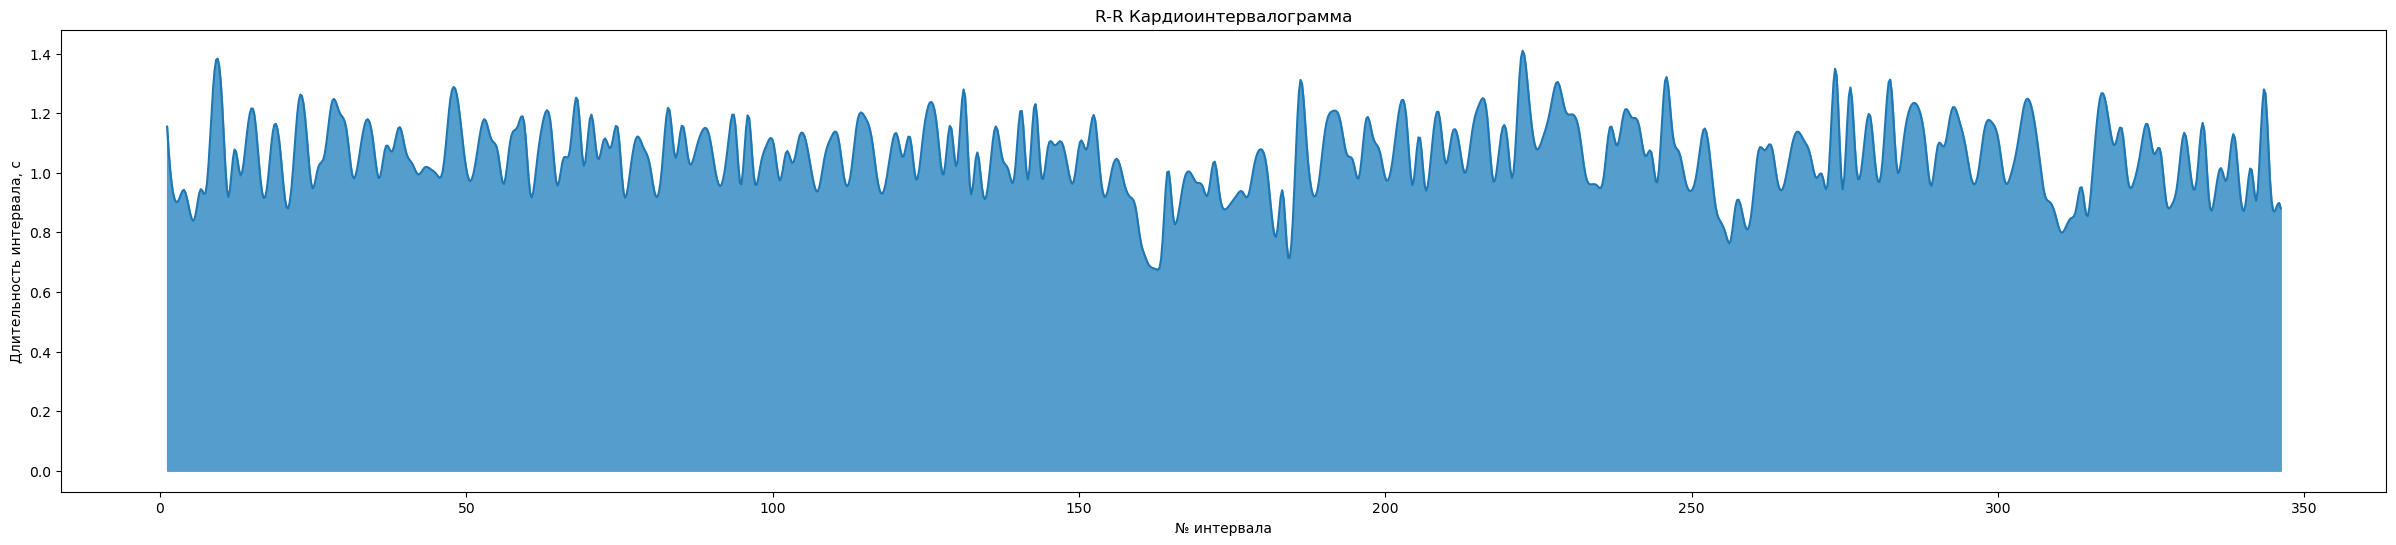

In [10]:
plt.figure(figsize=(30,6))
plt.plot(new_time,R_R_interp,)
plt.title('R-R Кардиоинтервалограмма')
plt.fill_between(new_time, R_R_interp, color='#539ecd')
plt.xlabel('№ интервала')
plt.ylabel('Длительность интервала, с')

### Переход из частотной во временную область

In [11]:
R_R_spectral = np.fft.fft(R_R_centered)

In [12]:
R_R_spectral.shape

(1381,)

Смотрим выходные данные

In [13]:
R_R_spectral[:10]

array([ 2.18158824e-14+3.88578059e-16j,  6.10132603e+00+5.94408488e-01j,
       -2.45790873e+01-1.59494142e+01j,  1.10986031e+01+6.55644834e+00j,
       -3.31089465e+01-1.23285312e+01j,  1.65341143e+01-8.84524283e+00j,
        2.40029059e+00-3.50780055e+00j, -3.50615878e+00+1.81513255e+01j,
       -1.70703848e+01-7.88312713e+00j, -2.29850902e+00+3.33245907e-01j])

Задаём частоту дискретизации и преобразовываем ось

In [14]:
fs = 4
frequencies = np.fft.fftfreq(len(R_R_interp), d=1/fs)  # d — интервал дискретизации (1/fs)

In [15]:
frequencies[:10]

array([0.        , 0.00289645, 0.0057929 , 0.00868936, 0.01158581,
       0.01448226, 0.01737871, 0.02027516, 0.02317161, 0.02606807])

Спектр (15) является зеркально симметричным (двусторонним) относительно своей центральной точки l=(N-l)/2, то есть: Xi=XN-i поэтому для его графического отображения и последующего исследования достаточно первых (N-l)/2 амплитуд (односторонний спектр). При переходе от двустороннего спектра к одностороннему необходимо нормирование его амплитуд умножением на √2 (нормировка спектра мощности производится умножением на 2)

Мощность спектра

$$ PSD(f)=\frac{2\cdot |z|{}^{2}}{f_{s}\cdot N}$$

In [16]:
N_interp = len(R_R_interp)

Мощность спектра в секундах

In [17]:
psd_sec = 2 * np.abs(R_R_spectral) ** 2 / (fs *N_interp)  

Мощность спектра в милисекундах

In [18]:
psd= psd_sec* 1000000

Маска для нижних  частот (в которых работает наше тело?)

In [19]:
low_freq_mask = (frequencies > 0) & (frequencies < 0.4)

Маски для каждой категории частот:

In [20]:
hf_mask = (frequencies > 0.15) & (frequencies <= 0.4)
lf_mask = (frequencies > 0.04) & (frequencies <= 0.15)
vlf_mask = (frequencies > 0.003) & (frequencies <= 0.04)
ulf_mask = (frequencies > 0) & (frequencies <= 0.003)

### Расчёт совокупной мощности спектра

In [21]:
hf = np.trapz(psd[hf_mask], frequencies[hf_mask])
lf = np.trapz(psd[lf_mask], frequencies[lf_mask])
vlf = np.trapz(psd[vlf_mask], frequencies[vlf_mask])
ulf = np.trapz(psd[ulf_mask], frequencies[ulf_mask])

Text(0, 0.5, 'мс^2')

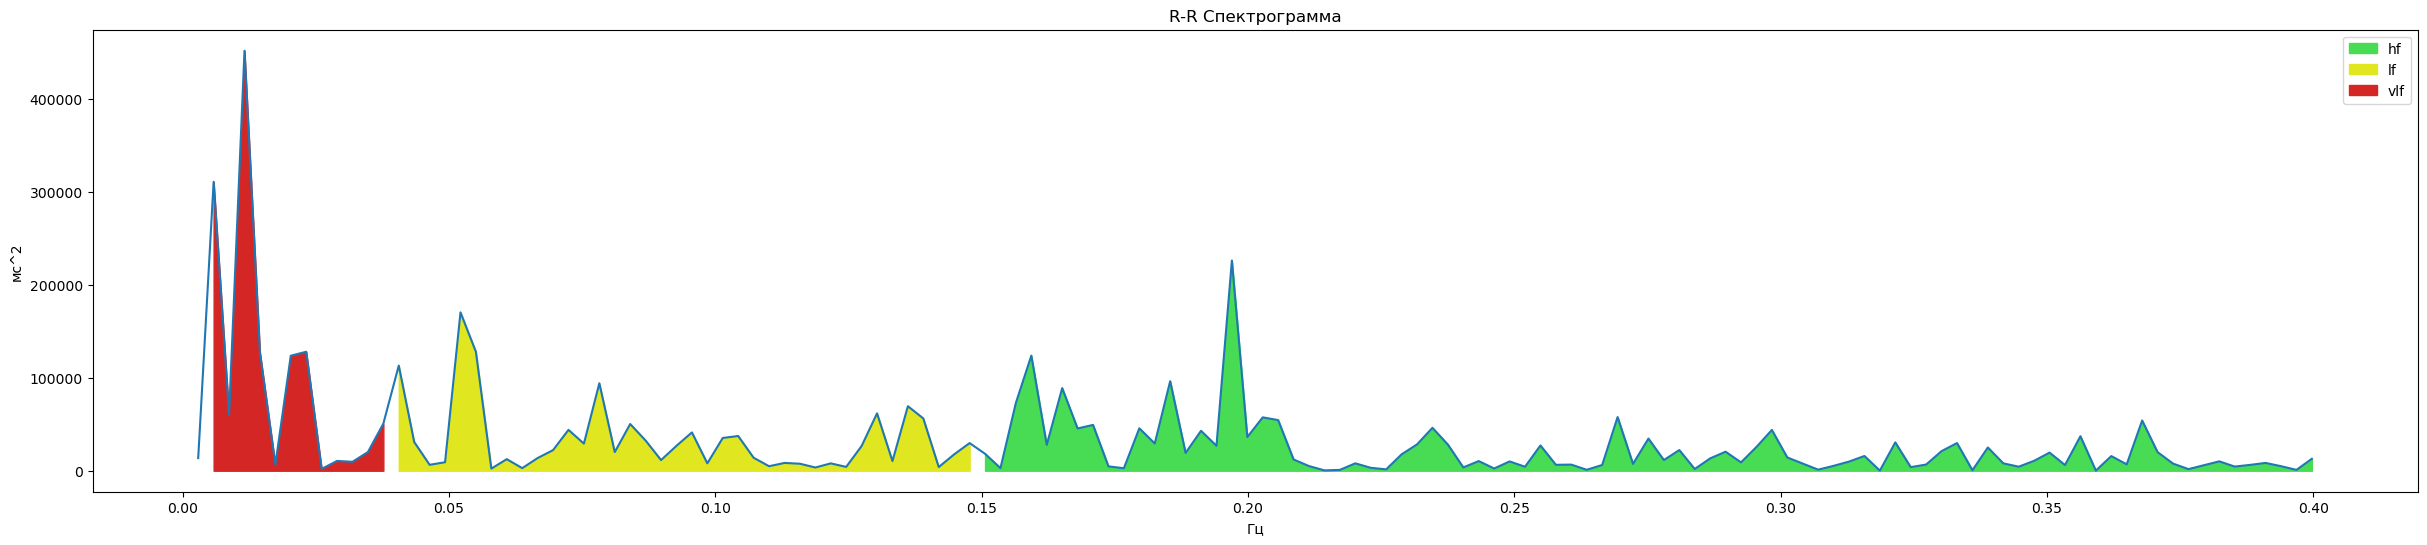

In [22]:
plt.figure(figsize=(30,6))
plt.plot(frequencies[low_freq_mask], psd[low_freq_mask])
plt.title('R-R Спектрограмма')
plt.fill_between(frequencies[hf_mask], psd[hf_mask], color="#48dc55",label = 'hf')
plt.fill_between(frequencies[lf_mask], psd[lf_mask], color="#e0e720",label = 'lf')
plt.fill_between(frequencies[vlf_mask], psd[vlf_mask], color="#d52626",label = 'vlf')

plt.legend()
plt.xlabel('Гц')
plt.ylabel('мс^2')

In [23]:
TP = hf + lf + vlf + ulf
print(f'Мощность спектра: {TP:.0f} мс^2')

Мощность спектра: 12354 мс^2
